# 🔬 WM-811K 晶圓瑕疵圖譜 EDA (探索性資料分析)

本筆記本的目標：
1. 讀取高達 2GB 的真實晶圓圖資料檔 (`LSWMD.pkl`)。
2. 解析這 81 萬片晶圓的基本資訊（瑕疵種類、資料分佈）。
3. **視覺化 (Visualization)：** 實際畫出這 9 大類瑕疵的圖形，去感受它們的物理成因。

## 1. 載入套件與讀取資料
⚠️ 檔案有 2GB，讀取約需 10~20 秒，請耐心等候。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("[INFO] 正在載入 2GB 的 PKL 檔案...")
df = pd.read_pickle('../data/LSWMD.pkl')

print(f"[OK] 載入完成！資料筆數：{df.shape[0]:,} 片晶圓")
df.head()

[INFO] 正在載入 2GB 的 PKL 檔案...


[OK] 載入完成！資料筆數：811,457 片晶圓


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


## 2. 標籤清理 (Data Cleaning)
原始資料的 `failureType` (瑕疵種類) 格式是被包在 Array 裡面的（例如 `[['Center']]`），我們需要把它萃取成純字串格式，方便後續統計。

In [2]:
def extract_string(x):
    if x is None or len(x) == 0:
        return 'Unknown'
    return str(x[0][0])

# 清理瑕疵標籤
df['failureType'] = df['failureType'].apply(extract_string)
# 把 'none' 統一首字母大寫為 'None'
df['failureType'] = df['failureType'].replace({'none': 'None'})

print("清理後的標籤種類清單：")
print(df['failureType'].unique())

清理後的標籤種類清單：
['None' 'Loc' 'Unknown' 'Edge-Loc' 'Center' 'Edge-Ring' 'Scratch' 'Random'
 'Near-full' 'Donut']


## 3. 瑕疵類別不平衡分析
在真實半導體廠中，大部分的晶圓都是正常的 (None) 或是未標記的 (Unknown)。真正被標記出特定形狀瑕疵的晶圓佔極少數。

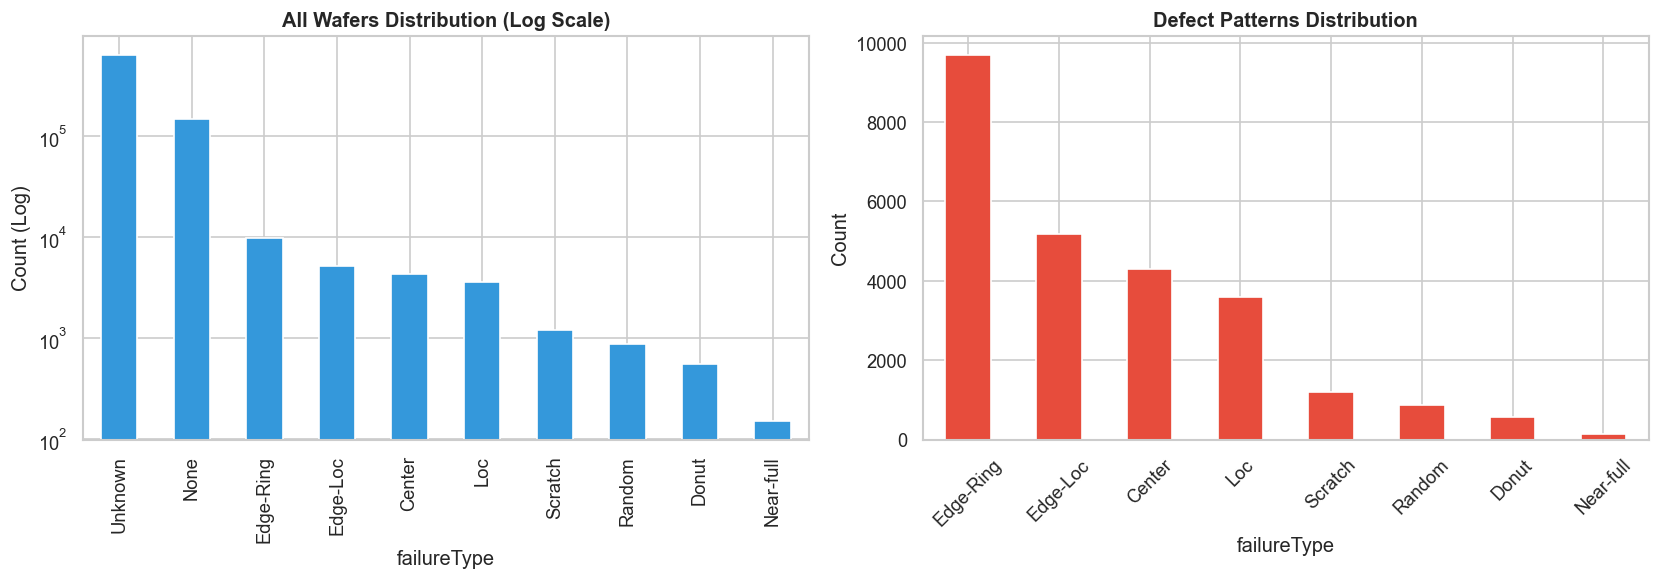

各類別詳細數量：
failureType
Unknown      638507
None         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [3]:
# 統計各種類別的數量
counts = df['failureType'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 畫出所有資料的分佈（包含 Unknown 和 None）
counts.plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_yscale('log') # 使用對數坐標軸，因為數量差異太大
axes[0].set_title('All Wafers Distribution (Log Scale)', fontweight='bold')
axes[0].set_ylabel('Count (Log)')

# 篩選出「有具體瑕疵形狀」的資料（排除 Unknown 和 None）
defect_counts = counts.drop(['Unknown', 'None'], errors='ignore')
defect_counts.plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Defect Patterns Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/01_defect_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("各類別詳細數量：")
print(counts)

## 4. 晶圓瑕疵圖譜視覺化 (Wafer Map Visualization) 🔥
這就是這份資料庫的精華！我們直接把二維陣列 `waferMap` 畫成圖像。晶圓圖上的數值意義：
- `0` = 背景 (空白區域)
- `1` = 正常晶粒 (Pass Die)
- `2` = 故障晶粒 (Fail Die) -> **這就是構成瑕疵圖案的點**

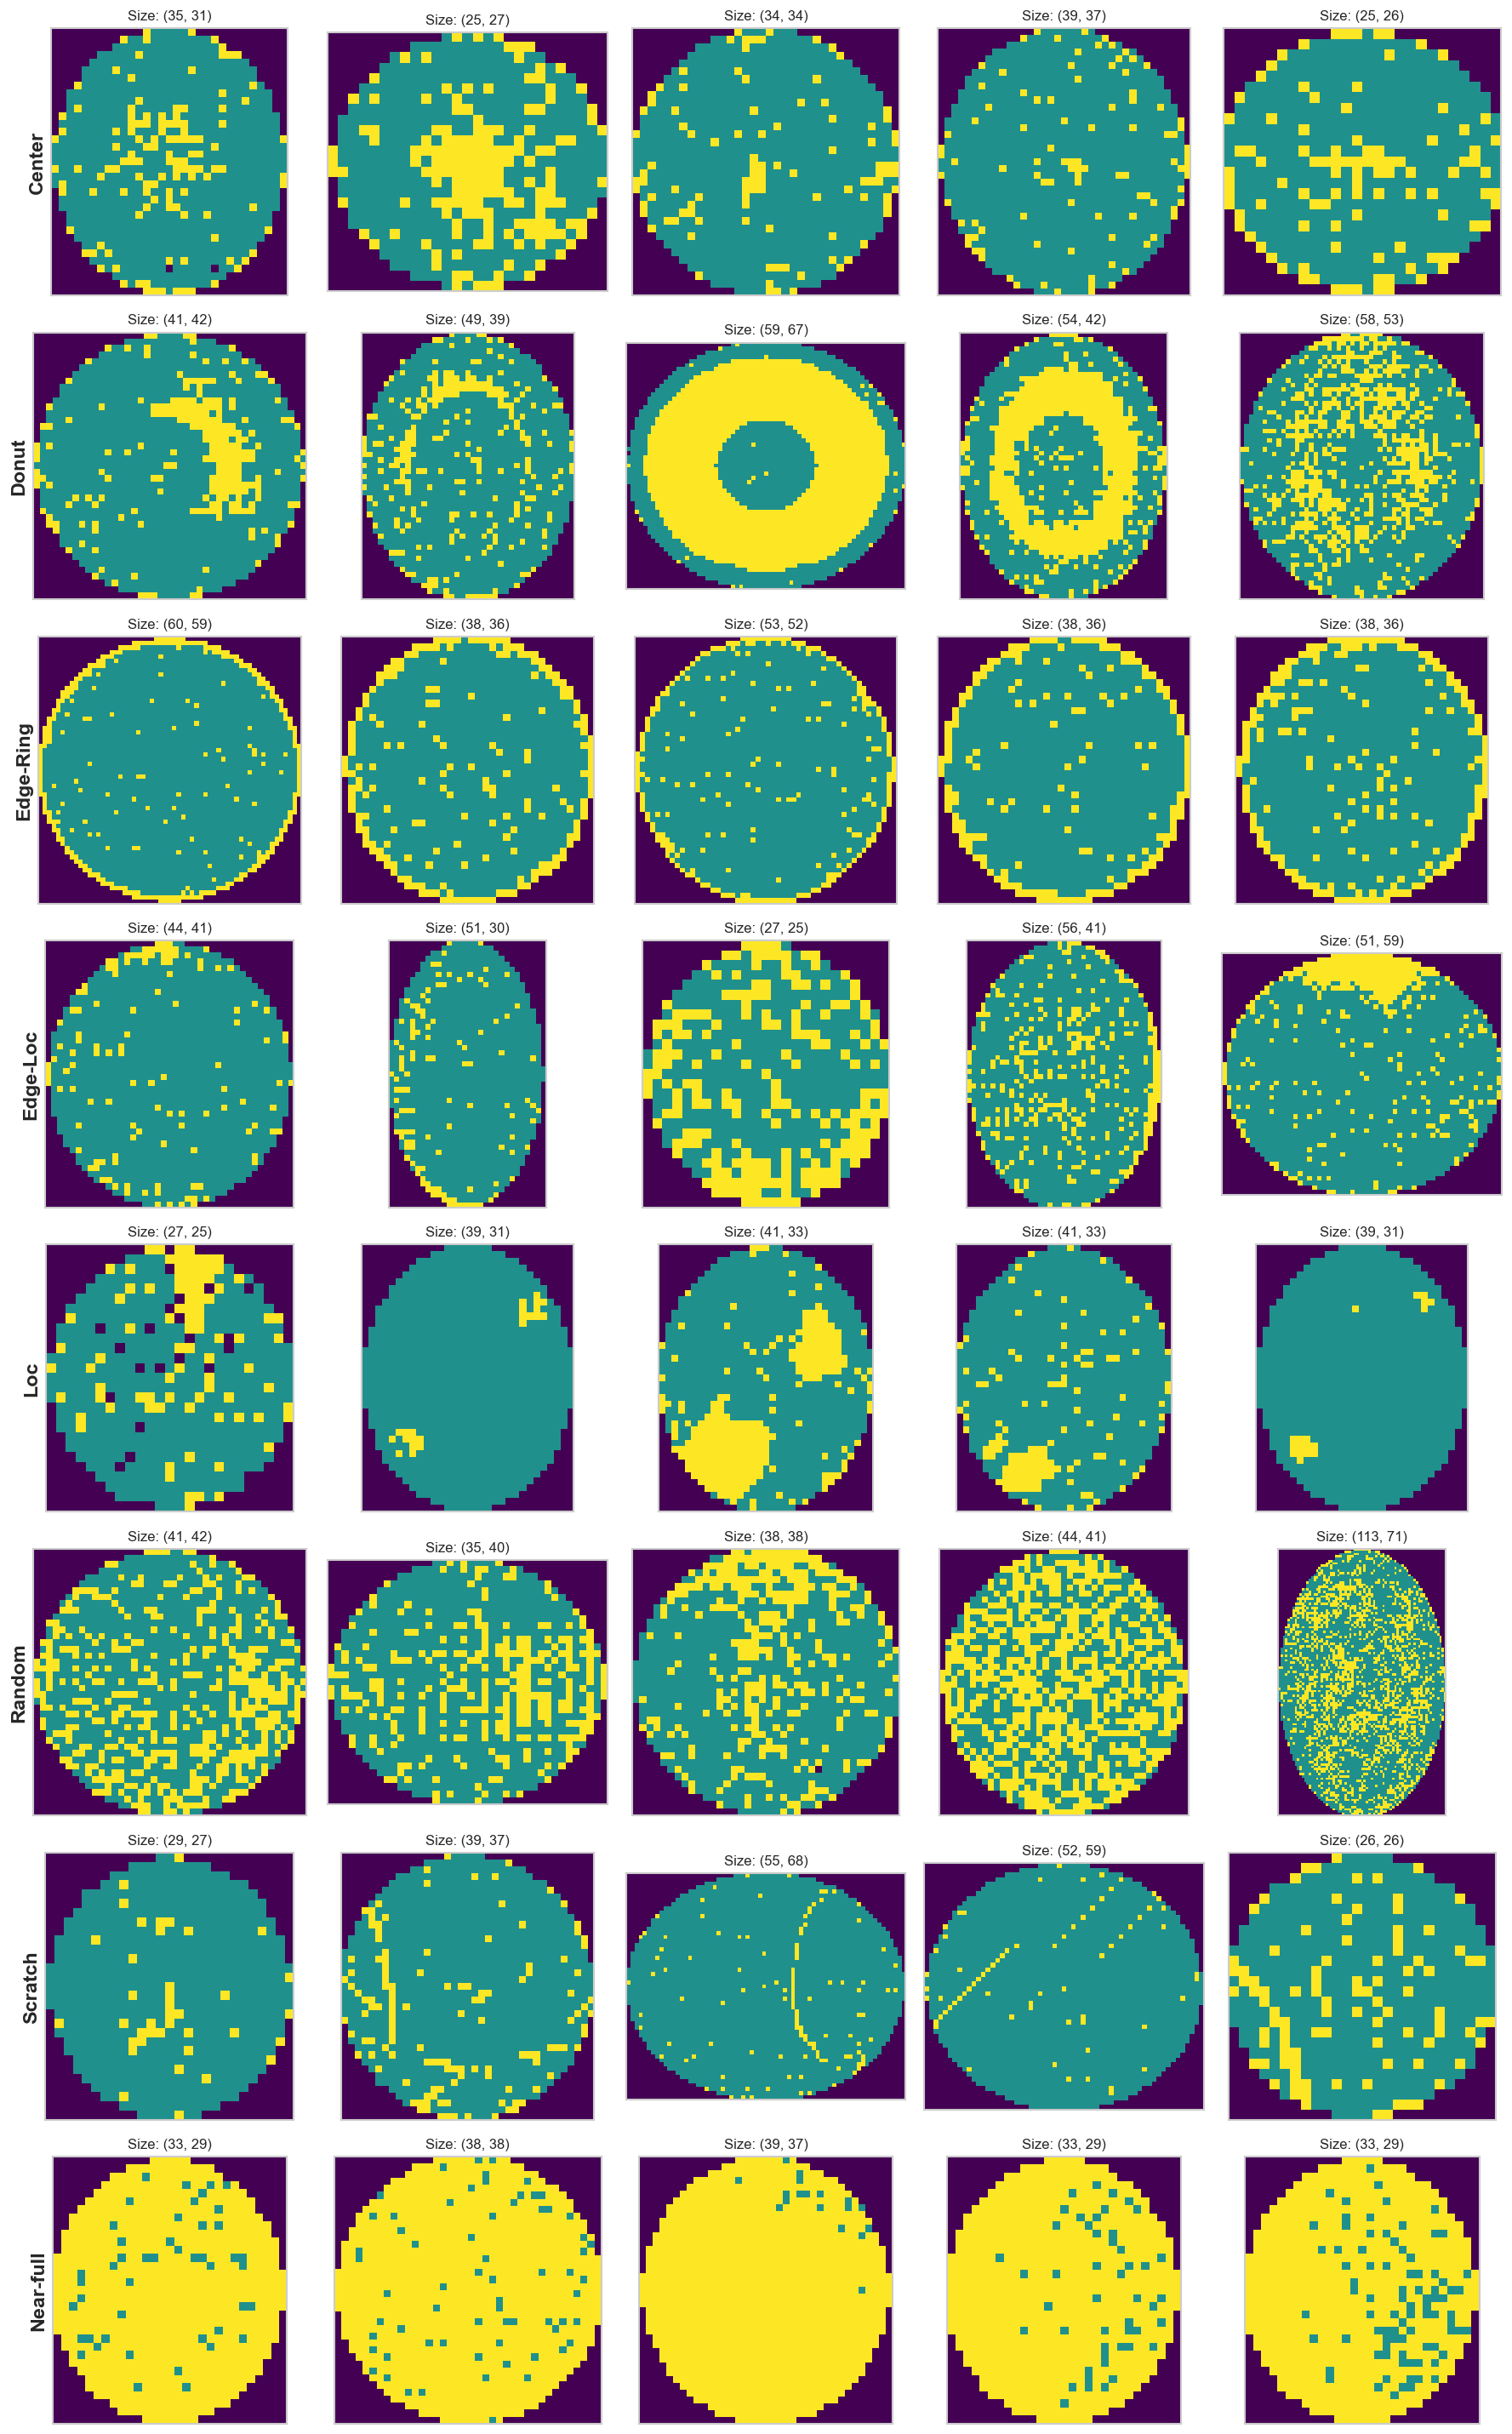

In [4]:
# 定義要展示的 8 種真實瑕疵
defect_types = ['Center', 'Donut', 'Edge-Ring', 'Edge-Loc', 'Loc', 'Random', 'Scratch', 'Near-full']

fig, axes = plt.subplots(len(defect_types), 5, figsize=(15, 3 * len(defect_types)))

for i, defect in enumerate(defect_types):
    # 隨機挑出 5 張該類型的晶圓
    samples = df[df['failureType'] == defect].sample(5, random_state=42)
    
    for j, (index, row) in enumerate(samples.iterrows()):
        ax = axes[i, j]
        # 畫出晶圓圖 (cmap='viridis' 會讓 0,1,2 變成深藍、淺藍、黃綠色)
        ax.imshow(row['waferMap'], cmap='viridis', interpolation='none')
        
        if j == 0:
            ax.set_ylabel(defect, fontsize=14, fontweight='bold')
        
        ax.set_title(f"Size: {row['waferMap'].shape}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('../figures/02_defect_patterns_gallery.png', dpi=200, bbox_inches='tight')
plt.show()

### 物理成因快速對照表：
- **Center (中心集中):** 通常對應到 CVD / 蝕刻機台內的熱力學溫度梯度失衡。
- **Edge-Ring (邊緣環狀):** 流體力學的邊緣效應 (Edge Effect)，或氣流分佈不均。
- **Scratch (刮痕):** 機械搬運問題，通常是單一斜線。
- **Donut (甜甜圈):** 電漿物理問題，腔體內電漿濃度呈現中空分佈。

---
**⚠️ 觀察：** 你會發現每一張圖的 `Size` (解析度) 都不同！這是因為每種晶片切出來的大小不一樣。所以我們的**下一步 (Phase 2)** 就是要寫程式把它們全部 Resize 變成一樣大小的影像 Tensor，才能送進 CNN 訓練！